# Mean-Reversion Tests

Before building the trading strategy, this notebook asks: **is there actually a signal?**

Four tests in increasing order of directness:

| Test | What it checks |
|------|----------------|
| 1. Predictive regression | Does $z_{i,t}$ negatively predict $r_{i,t+1}$? |
| 2. AR(1) autocorrelation | Is the residual series itself negatively autocorrelated? |
| 3. Quantile sorting | Do low-z stocks outperform high-z stocks next day? |
| 4. ADF stationarity | Do cumulative residuals revert rather than drift? |

A signal can be statistically real but not economically profitable. These tests establish the statistical case; the backtest (notebook 4) handles the economic case.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "../data/processed"

PCA_OUTPUT_SUFFIX = "_L126_K10_M20"  # must match OUTPUT_SUFFIX in notebook 2.0

**Timing convention:** residuals and z-scores are indexed by first tradable date. A row labeled $t$ was computed using information available through $t-1$. Predictive tests pair $z_{i,t}$ with future quantities such as `log_returns.shift(-1)[t]` and `residuals.shift(-1)[t]`. Do not relabel residuals to $t-1$.

In [15]:
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")
residuals   = pd.read_parquet(f"{PROCESSED}/residual_returns{PCA_OUTPUT_SUFFIX}.parquet")
zscores     = pd.read_parquet(f"{PROCESSED}/residual_zscores{PCA_OUTPUT_SUFFIX}.parquet")

# Align to common columns and index — z-scores define the valid universe
common_cols = residuals.columns.intersection(zscores.columns).intersection(log_returns.columns)
residuals   = residuals[common_cols]
zscores     = zscores[common_cols]
log_returns = log_returns[common_cols]

common_idx = residuals.index.intersection(zscores.index)
residuals  = residuals.loc[common_idx]
zscores    = zscores.loc[common_idx]

print(f"Log returns : {log_returns.shape}")
print(f"Residuals   : {residuals.shape}")
print(f"Z-scores    : {zscores.shape}")

Log returns : (3730, 200)
Residuals   : (3584, 200)
Z-scores    : (3584, 200)


In [16]:
# Align for predictive regressions
# At date t: z_{i,t} predicts r_{i,t+1} and eps_{i,t+1}
# Use shift(-1) on returns/residuals so they align on the z-score index
r_next   = log_returns.shift(-1).reindex(zscores.index)   # r_{i,t+1}
eps_next = residuals.shift(-1).reindex(zscores.index)     # ε_{i,t+1}

# Stack into long-format panel
panel = pd.concat({
    "z_score" : zscores.stack(),
    "r_next"  : r_next.stack(),
    "eps_next": eps_next.stack(),
}, axis=1).dropna().reset_index()
panel.columns = ["date", "ticker", "z_score", "r_next", "eps_next"]

print(f"Panel observations: {len(panel):,}")
print(f"Date range         : {panel['date'].min().date()}  →  {panel['date'].max().date()}")
panel.head()

Panel observations: 716,600
Date range         : 2012-01-25  →  2026-04-24


,date,ticker,z_score,r_next,eps_next
0,2012-01-25,TSLA,0.445662,0.034092,0.016557
1,2012-01-25,NVDA,1.022547,-0.009473,-0.010692
2,2012-01-25,AAPL,-2.907532,-0.004555,0.032317
3,2012-01-25,MSFT,-1.543018,-0.002032,-0.000680
4,2012-01-25,AMZN,-0.025071,0.028969,0.003246


---
## Test 1 — Predictive Regression

We estimate two pooled panel regressions:

**Return regression** (more directly tradable):
$$r_{i,t+1} = a + b \cdot z_{i,t} + u_{i,t+1}$$

**Residual regression** (more directly tied to the model):
$$\varepsilon_{i,t+1} = a + b \cdot z_{i,t} + u_{i,t+1}$$

Mean reversion predicts $b < 0$: a high z-score today (idiosyncratic outperformance) should predict a lower-than-average return tomorrow.

Standard errors are clustered by date to account for cross-sectional dependence — on any given day, all stock residuals share a common shock.

In [17]:
X = sm.add_constant(panel["z_score"])

# Return regression
fit_r = sm.OLS(panel["r_next"], X).fit(
    cov_type="cluster", cov_kwds={"groups": panel["date"]}
)

# Residual regression
fit_e = sm.OLS(panel["eps_next"], X).fit(
    cov_type="cluster", cov_kwds={"groups": panel["date"]}
)

def reg_summary(label, fit):
    b      = fit.params["z_score"]
    t_stat = fit.tvalues["z_score"]
    pval   = fit.pvalues["z_score"]
    r2     = fit.rsquared
    n      = int(fit.nobs)
    stars  = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
    print(f"{label}")
    print(f"  b        = {b:.6f}{stars}")
    print(f"  t-stat   = {t_stat:.3f}")
    print(f"  p-value  = {pval:.4f}")
    print(f"  R²       = {r2:.6f}")
    print(f"  N        = {n:,}")
    print()

reg_summary("Return regression:  r_{i,t+1} = a + b·z_{i,t}", fit_r)
reg_summary("Residual regression: ε_{i,t+1} = a + b·z_{i,t}", fit_e)

Return regression:  r_{i,t+1} = a + b·z_{i,t}
  b        = 0.000021
  t-stat   = 1.199
  p-value  = 0.2304
  R²       = 0.000002
  N        = 716,600

Residual regression: ε_{i,t+1} = a + b·z_{i,t}
  b        = -0.000085***
  t-stat   = -5.673
  p-value  = 0.0000
  R²       = 0.000083
  N        = 716,600



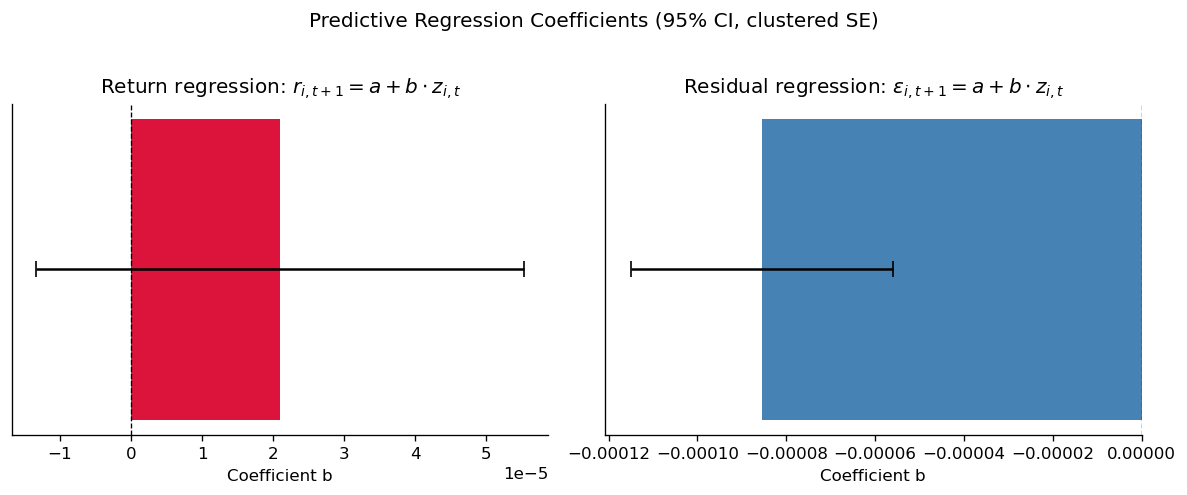

In [18]:
# Coefficient plot — visually confirm b < 0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, fit, title in zip(
    axes,
    [fit_r, fit_e],
    [r"Return regression: $r_{i,t+1} = a + b \cdot z_{i,t}$",
     r"Residual regression: $\varepsilon_{i,t+1} = a + b \cdot z_{i,t}$"],
):
    b   = fit.params["z_score"]
    ci  = fit.conf_int().loc["z_score"]
    ax.barh([0], [b], color="steelblue" if b < 0 else "crimson", height=0.4)
    ax.errorbar([b], [0], xerr=[[b - ci[0]], [ci[1] - b]], fmt="none", color="black", capsize=5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks([])
    ax.set_xlabel("Coefficient b")
    ax.set_title(title)

plt.suptitle("Predictive Regression Coefficients (95% CI, clustered SE)", y=1.02)
plt.tight_layout()
plt.show()

---
## Test 2 — AR(1) Residual Autocorrelation

For each stock we estimate:
$$\varepsilon_{i,t+1} = a_i + \phi_i \cdot \varepsilon_{i,t} + u_{i,t+1}$$

Mean reversion predicts $\phi_i < 0$. We report the distribution of $\phi_i$ across all stocks, and what fraction are negative and statistically significant.

In [19]:
ar1_results = {}

for ticker in tqdm(residuals.columns, desc="AR(1)"):
    eps = residuals[ticker].dropna()
    df  = pd.DataFrame({"eps_t": eps, "eps_lag": eps.shift(1)}).dropna()
    if len(df) < 50:
        continue
    fit = sm.OLS(df["eps_t"], sm.add_constant(df["eps_lag"])).fit()
    ar1_results[ticker] = {
        "phi"   : fit.params["eps_lag"],
        "tstat" : fit.tvalues["eps_lag"],
        "pvalue": fit.pvalues["eps_lag"],
    }

phi_df = pd.DataFrame(ar1_results).T

neg        = (phi_df["phi"] < 0).mean()
sig_neg    = ((phi_df["phi"] < 0) & (phi_df["pvalue"] < 0.05)).mean()
sig_pos    = ((phi_df["phi"] > 0) & (phi_df["pvalue"] < 0.05)).mean()

print(f"Mean φ                      : {phi_df['phi'].mean():.4f}")
print(f"Median φ                    : {phi_df['phi'].median():.4f}")
print(f"Fraction φ < 0              : {neg:.1%}")
print(f"Fraction φ < 0 & p < 0.05   : {sig_neg:.1%}")
print(f"Fraction φ > 0 & p < 0.05   : {sig_pos:.1%}")

AR(1): 100%|██████████| 200/200 [00:00<00:00, 1285.99it/s]

Mean φ                      : -0.0167
Median φ                    : -0.0169
Fraction φ < 0              : 76.5%
Fraction φ < 0 & p < 0.05   : 25.0%
Fraction φ > 0 & p < 0.05   : 2.0%


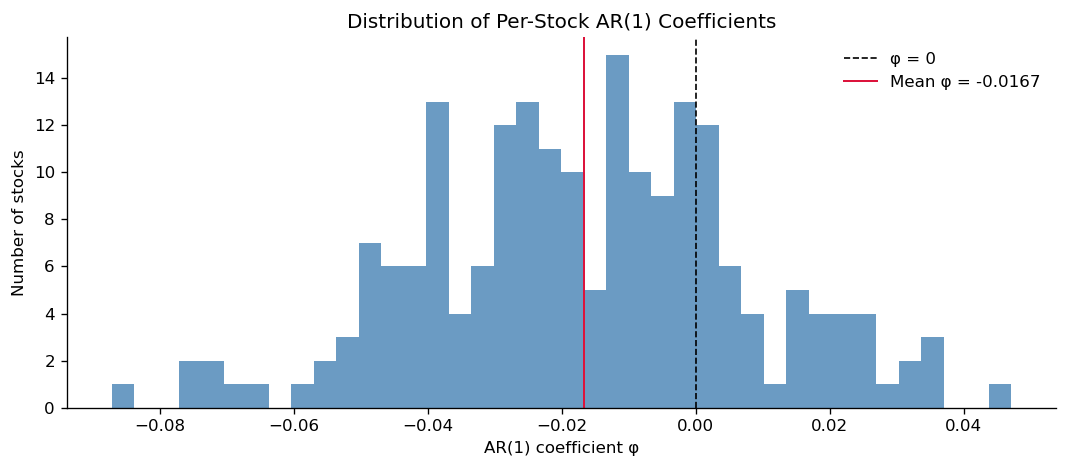

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(phi_df["phi"], bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0,                   color="black",  linewidth=1.0, linestyle="--", label="φ = 0")
ax.axvline(phi_df["phi"].mean(), color="crimson", linewidth=1.2, linestyle="-",  label=f"Mean φ = {phi_df['phi'].mean():.4f}")
ax.set_xlabel("AR(1) coefficient φ")
ax.set_ylabel("Number of stocks")
ax.set_title("Distribution of Per-Stock AR(1) Coefficients")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Robustness Diagnostic — AR(1)-Screened Residual Subset

Stocks whose residuals show statistically significant negative AR(1) (φ < 0, p < 0.10) may exhibit stronger mean reversion. This section checks whether the predictive regression coefficient becomes more negative in that subset.

> **Important:** this screen is estimated over the **full sample**. It is a diagnostic to understand the cross-sectional heterogeneity in mean-reversion strength, not an out-of-sample trading universe selection rule. The fully out-of-sample version is in notebook 5.0 (appendix).

In [21]:
AR1_MAX_P = 0.10
ar1_screened_names = phi_df[
    (phi_df["phi"] < 0) & (phi_df["pvalue"] < AR1_MAX_P)
].index.tolist()
print(f"AR(1)-screened diagnostic subset: {len(ar1_screened_names)} stocks")

zscores_ar1   = zscores[ar1_screened_names]
residuals_ar1 = residuals[ar1_screened_names]
r_next_ar1    = log_returns.shift(-1).reindex(index=zscores.index, columns=ar1_screened_names)
eps_next_ar1  = residuals.shift(-1).reindex(index=zscores.index, columns=ar1_screened_names)

panel_ar1 = pd.concat({
    "z_score" : zscores_ar1.stack(),
    "r_next"  : r_next_ar1.stack(),
    "eps_next": eps_next_ar1.stack(),
}, axis=1).dropna().reset_index()
panel_ar1.columns = ["date", "ticker", "z_score", "r_next", "eps_next"]

X_ar1 = sm.add_constant(panel_ar1["z_score"])
fit_r_ar1 = sm.OLS(panel_ar1["r_next"],   X_ar1).fit(cov_type="cluster", cov_kwds={"groups": panel_ar1["date"]})
fit_e_ar1 = sm.OLS(panel_ar1["eps_next"], X_ar1).fit(cov_type="cluster", cov_kwds={"groups": panel_ar1["date"]})

print(f"\nPredictive regression — AR(1)-screened subset (N={len(panel_ar1):,} obs)")
reg_summary("  Return regression",   fit_r_ar1)
reg_summary("  Residual regression", fit_e_ar1)

AR(1)-screened diagnostic subset: 65 stocks

Predictive regression — AR(1)-screened subset (N=232,895 obs)
  Return regression
  b        = -0.000007
  t-stat   = -0.236
  p-value  = 0.8133
  R²       = 0.000000
  N        = 232,895

  Residual regression
  b        = -0.000281***
  t-stat   = -13.075
  p-value  = 0.0000
  R²       = 0.001121
  N        = 232,895



---
## Test 3 — Quantile Sorting

Each day we sort all stocks into deciles by residual z-score and compute the average next-day return for each decile. Mean reversion predicts a **downward-sloping** pattern: stocks with the lowest z-scores (most idiosyncratically oversold) should have the highest next-day returns.

The long-short spread is:
$$R_{LS,t+1} = R_{\text{low-z},t+1} - R_{\text{high-z},t+1}$$

A positive mean spread is the primary signature of mean reversion.

Decile sort: 100%|██████████| 3583/3583 [00:03<00:00, 920.32it/s]


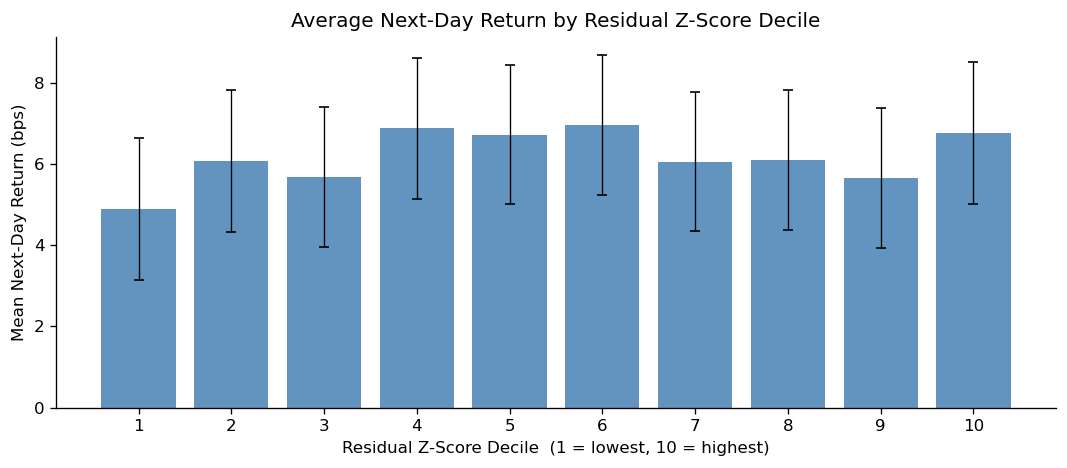

Long-short spread (D1 − D10): -1.87 bps/day
Annualised (×252)            : -4.72%


In [22]:
N_DECILES = 10
decile_ret_records = []

# Align: z at date t, return at date t+1
common_dates = zscores.index[zscores.index.isin(r_next.index)]

for date in tqdm(common_dates[:-1], desc="Decile sort"):
    z_row = zscores.loc[date]
    r_row = r_next.loc[date]
    valid = z_row.notna() & r_row.notna()
    if valid.sum() < N_DECILES * 2:
        continue
    try:
        deciles = pd.qcut(z_row[valid], q=N_DECILES, labels=False, duplicates="drop")
    except ValueError:
        continue
    for d in range(N_DECILES):
        mask = deciles == d
        if mask.sum() == 0:
            continue
        decile_ret_records.append({"date": date, "decile": d + 1, "ret": r_row[valid][mask].mean()})

decile_df   = pd.DataFrame(decile_ret_records)
decile_mean = decile_df.groupby("decile")["ret"].mean() * 1e4   # in basis points
decile_se   = decile_df.groupby("decile")["ret"].sem()   * 1e4

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decile_mean.index, decile_mean.values, yerr=decile_se.values,
       color="steelblue", edgecolor="none", alpha=0.85, capsize=3, error_kw={"linewidth": 0.8})
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("Residual Z-Score Decile  (1 = lowest, 10 = highest)")
ax.set_ylabel("Mean Next-Day Return (bps)")
ax.set_title("Average Next-Day Return by Residual Z-Score Decile")
ax.set_xticks(range(1, N_DECILES + 1))
plt.tight_layout()
plt.show()

ls_spread_bps = decile_mean.iloc[0] - decile_mean.iloc[-1]
print(f"Long-short spread (D1 − D10): {ls_spread_bps:.2f} bps/day")
print(f"Annualised (×252)            : {ls_spread_bps * 252 / 100:.2f}%")

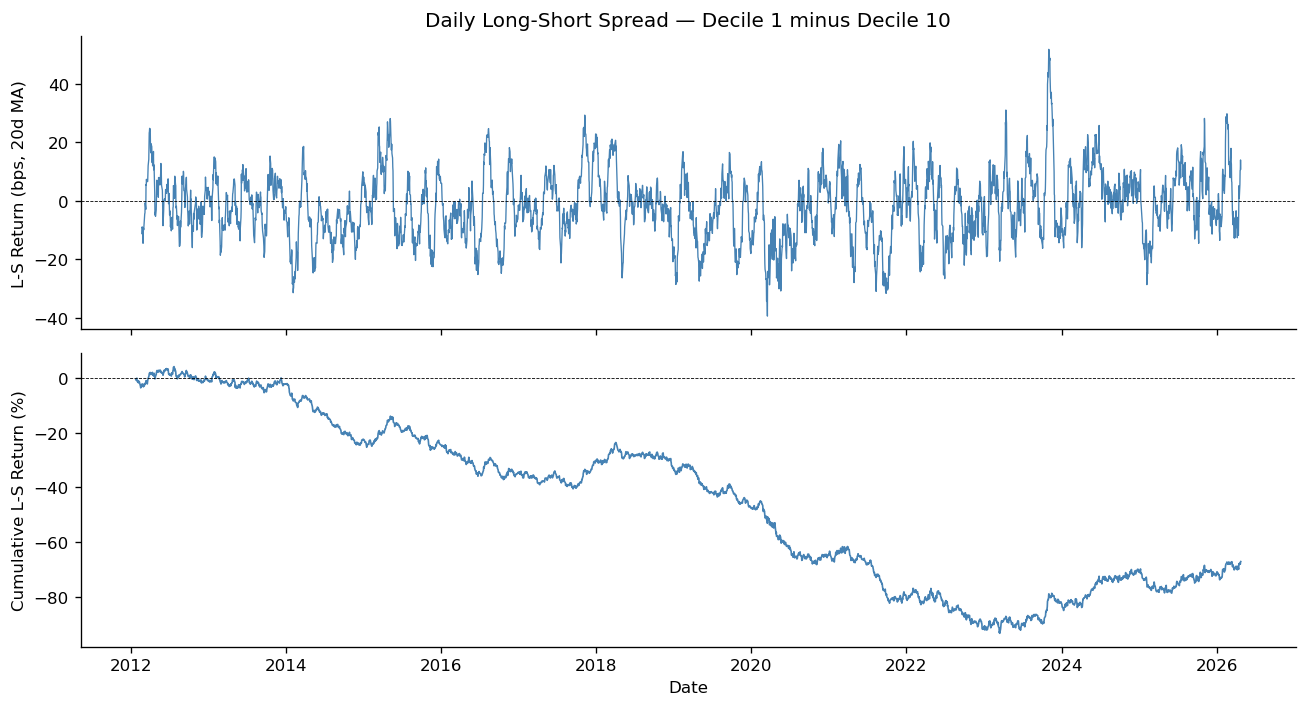

Mean daily L-S return : -1.874 bps
t-statistic           : -2.218


In [23]:
# Daily L-S spread time series
ls_daily = (
    decile_df[decile_df["decile"] == 1].set_index("date")["ret"]
    - decile_df[decile_df["decile"] == N_DECILES].set_index("date")["ret"]
).sort_index()

cum_ls = ls_daily.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ls_daily.index, ls_daily.rolling(20).mean() * 1e4, color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("L-S Return (bps, 20d MA)")
axes[0].set_title("Daily Long-Short Spread — Decile 1 minus Decile 10")

axes[1].plot(cum_ls.index, cum_ls.values * 1e2, color="steelblue", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Cumulative L-S Return (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

ls_mean  = ls_daily.mean() * 1e4
ls_t     = ls_daily.mean() / (ls_daily.std() / np.sqrt(len(ls_daily)))
print(f"Mean daily L-S return : {ls_mean:.3f} bps")
print(f"t-statistic           : {ls_t:.3f}")

---
## Test 4 — ADF Stationarity Test

We run the Augmented Dickey-Fuller test on the **cumulative residual** for each stock:

$$X_{i,t} = \sum_{\tau \leq t} \varepsilon_{i,\tau}$$

The null hypothesis is a unit root (random walk — no mean reversion). Rejecting the null supports stationarity — the cumulative residual tends to revert rather than drift.

This is a supporting test, not the centrepiece. Some stocks may have stationary residuals while others do not.

In [24]:
cum_residuals = residuals.cumsum()
adf_records   = {}

for ticker in tqdm(residuals.columns, desc="ADF"):
    series = cum_residuals[ticker].dropna()
    if len(series) < 50:
        continue
    stat, pval, *_ = adfuller(series, autolag="AIC")
    adf_records[ticker] = {"stat": stat, "pvalue": pval}

adf_df = pd.DataFrame(adf_records).T

pct_5  = (adf_df["pvalue"] < 0.05).mean()
pct_10 = (adf_df["pvalue"] < 0.10).mean()

print(f"Stocks tested                  : {len(adf_df)}")
print(f"Reject unit root at 5%  level  : {pct_5:.1%}")
print(f"Reject unit root at 10% level  : {pct_10:.1%}")
print(f"Mean ADF statistic             : {adf_df['stat'].mean():.3f}")

ADF: 100%|██████████| 200/200 [00:06<00:00, 31.12it/s]

Stocks tested                  : 200
Reject unit root at 5%  level  : 28.5%
Reject unit root at 10% level  : 40.0%
Mean ADF statistic             : -2.213


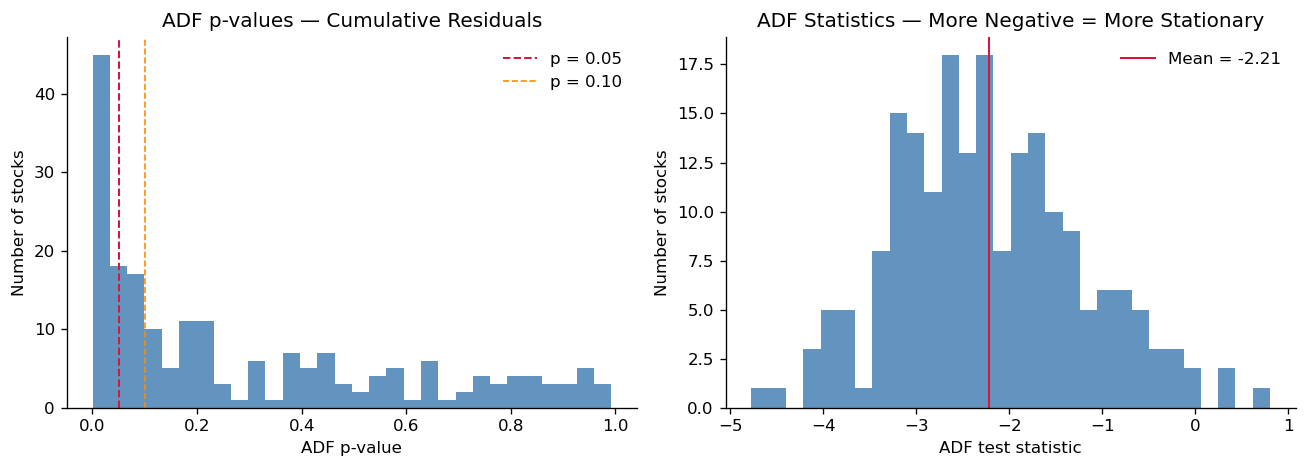

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(adf_df["pvalue"], bins=30, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(0.05, color="crimson",  linewidth=1.2, linestyle="--", label="p = 0.05")
ax.axvline(0.10, color="darkorange", linewidth=1.0, linestyle="--", label="p = 0.10")
ax.set_xlabel("ADF p-value")
ax.set_ylabel("Number of stocks")
ax.set_title("ADF p-values — Cumulative Residuals")
ax.legend(frameon=False)

ax = axes[1]
ax.hist(adf_df["stat"], bins=30, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(adf_df["stat"].mean(), color="crimson", linewidth=1.2, linestyle="-",
           label=f"Mean = {adf_df['stat'].mean():.2f}")
ax.set_xlabel("ADF test statistic")
ax.set_ylabel("Number of stocks")
ax.set_title("ADF Statistics — More Negative = More Stationary")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

---
## Summary

Collect the key numbers from all four tests.

In [26]:
print("=" * 60)
print("MEAN-REVERSION TEST SUMMARY")
print("=" * 60)

print("\nTest 1 — Predictive regression")
print(f"  Return regression   b = {fit_r.params['z_score']:.6f}  "
      f"(t={fit_r.tvalues['z_score']:.2f}, p={fit_r.pvalues['z_score']:.4f})")
print(f"  Residual regression b = {fit_e.params['z_score']:.6f}  "
      f"(t={fit_e.tvalues['z_score']:.2f}, p={fit_e.pvalues['z_score']:.4f})")

print("\nTest 2 — AR(1) autocorrelation")
print(f"  Mean φ     = {phi_df['phi'].mean():.4f}")
print(f"  Median φ   = {phi_df['phi'].median():.4f}")
print(f"  % φ < 0    = {(phi_df['phi'] < 0).mean():.1%}")
print(f"  % sig & <0 = {sig_neg:.1%}")

print("\nTest 3 — Quantile sorting")
print(f"  L-S spread (D1−D10) = {ls_spread_bps:.2f} bps/day")
print(f"  t-statistic         = {ls_t:.3f}")

print("\nTest 4 — ADF stationarity")
print(f"  Reject unit root @5%  = {pct_5:.1%} of stocks")
print(f"  Reject unit root @10% = {pct_10:.1%} of stocks")

print("\n" + "=" * 60)

MEAN-REVERSION TEST SUMMARY

Test 1 — Predictive regression
  Return regression   b = 0.000021  (t=1.20, p=0.2304)
  Residual regression b = -0.000085  (t=-5.67, p=0.0000)

Test 2 — AR(1) autocorrelation
  Mean φ     = -0.0167
  Median φ   = -0.0169
  % φ < 0    = 76.5%
  % sig & <0 = 25.0%

Test 3 — Quantile sorting
  L-S spread (D1−D10) = -1.87 bps/day
  t-statistic         = -2.218

Test 4 — ADF stationarity
  Reject unit root @5%  = 28.5% of stocks
  Reject unit root @10% = 40.0% of stocks

